In [1]:
import numpy as np
import pandas as pd
import neurokit2 as nk
import matplotlib.pyplot as plt
from module.filter.ecg_filter import *

In [2]:
# 参数
sampling_rate = 500

In [3]:
# 读取数据
data_path = "./data/processed_data/ecg_signals.pkl"
df = pd.read_pickle(data_path)

In [4]:
df.head()

,file,start_idx,end_idx,signal_quality,ecg_segment
0,20250521001_2025-05-21 18_45_58_b.csv,0,5000,0.0,"[-517.0, -523.0, -529.0, -535.0, -538.0, -538...."
1,20250521001_2025-05-21 18_45_58_b.csv,4000,9000,0.0,"[-801.0, -800.0, -798.0, -800.0, -799.0, -811...."
2,20250521001_2025-05-21 18_45_58_b.csv,8000,13000,0.0,"[-1014.0, -1009.0, -1003.0, -1003.0, -1011.0, ..."
3,20250521001_2025-05-21 18_48_11_b.csv,0,5000,0.0,"[-611.0, -608.0, -605.0, -608.0, -604.0, -600...."
4,20250521001_2025-05-21 18_48_11_b.csv,4000,9000,0.0,"[-674.0, -673.0, -679.0, -675.0, -675.0, -678...."


In [5]:
df['normalized_ecg'] = df["ecg_segment"].apply(lambda x: adb_2_ecg(x))
df['denoised_ecg'] = df['normalized_ecg'].apply(lambda x: wt_filter(highpass_filter(x, fs=sampling_rate), wavelet="db4", threshold=0.1))

In [6]:
ecg = df['denoised_ecg'][0]
process_signal, info = nk.ecg_process(ecg, sampling_rate=sampling_rate)

In [7]:
info

{'method_peaks': 'neurokit',
 'method_fixpeaks': 'None',
 'ECG_R_Peaks': array([ 162,  357,  676,  996, 1289, 1587, 1886, 2190, 2485, 2774, 3058,
        3336, 3613, 3890, 4167, 4445, 4725]),
 'ECG_R_Peaks_Uncorrected': array([ 162,  357,  712,  996, 1289, 1587, 1886, 2190, 2485, 2774, 3058,
        3336, 3613, 3890, 4167, 4445, 4725]),
 'ECG_fixpeaks_ectopic': [2],
 'ECG_fixpeaks_missed': [],
 'ECG_fixpeaks_extra': [],
 'ECG_fixpeaks_longshort': [1],
 'ECG_fixpeaks_method': 'kubios',
 'ECG_fixpeaks_rr': array([0.570375, 0.39    , 0.71    , 0.568   , 0.586   , 0.596   ,
        0.598   , 0.608   , 0.59    , 0.578   , 0.568   , 0.556   ,
        0.554   , 0.554   , 0.554   , 0.556   , 0.56    ]),
 'ECG_fixpeaks_drrs': array([-0.01558744, -4.3359375 ,  7.69230769, -3.41346154,  0.43269231,
         0.24038462,  0.04807692,  0.24038462, -0.43269231, -0.28846154,
        -0.24038462, -0.28846154, -0.04807692,  0.        ,  0.        ,
         0.04807692,  0.09615385]),
 'ECG_fixpeaks_mrrs

In [8]:
r_peaks = process_signal[process_signal["ECG_R_Peaks"] == 1].index  # R波峰
p_peaks = process_signal[process_signal["ECG_P_Peaks"] == 1].index  # P波峰
t_peaks = process_signal[process_signal["ECG_T_Peaks"] == 1].index  # T波峰
q_peaks = process_signal[process_signal["ECG_Q_Peaks"] == 1].index.values  # Q波谷
s_peaks = process_signal[process_signal["ECG_S_Peaks"] == 1].index.values  # S波谷

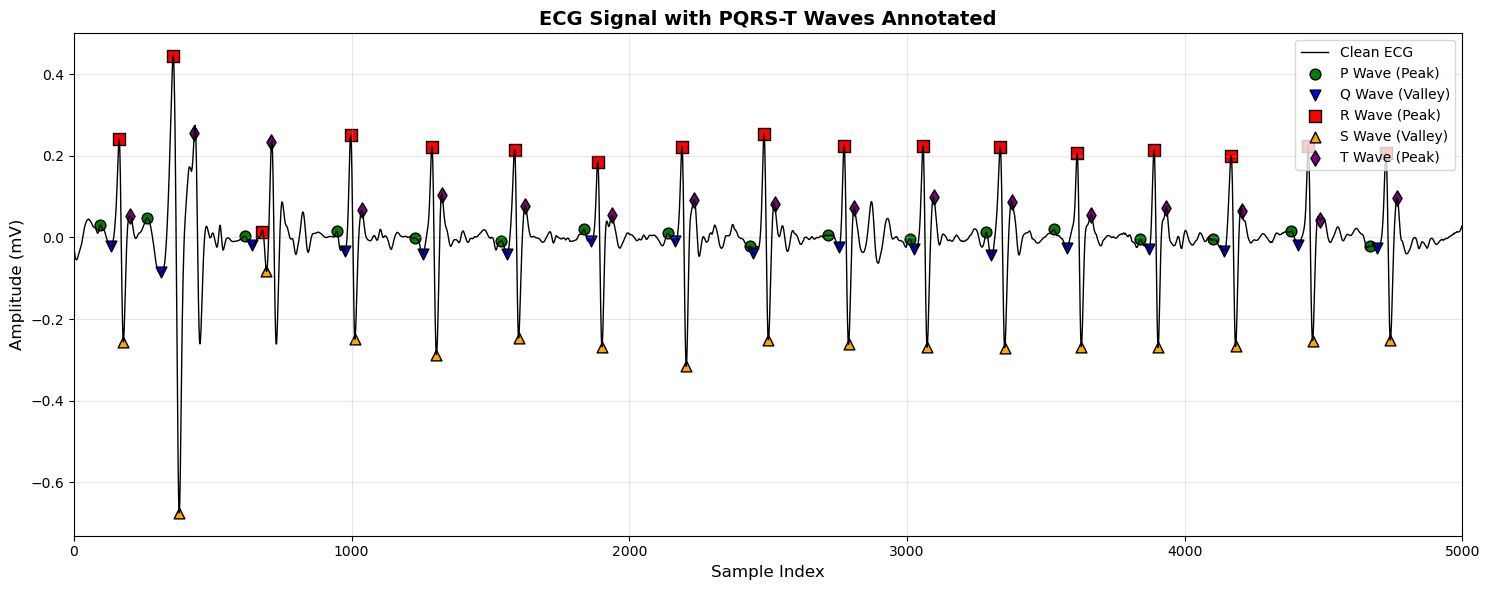

In [9]:
plt.figure(figsize=(15, 6))
plt.plot(process_signal["ECG_Clean"], color="black", linewidth=1, label="Clean ECG")
plt.scatter(info["ECG_P_Peaks"], process_signal.loc[info["ECG_P_Peaks"], "ECG_Clean"],
            color="green", s=60, marker="o", edgecolor="black", label="P Wave (Peak)")
plt.scatter(info["ECG_Q_Peaks"], process_signal.loc[info["ECG_Q_Peaks"], "ECG_Clean"],
            color="blue", s=60, marker="v", edgecolor="black", label="Q Wave (Valley)")
plt.scatter(info["ECG_R_Peaks"], process_signal.loc[info["ECG_R_Peaks"], "ECG_Clean"],
            color="red", s=80, marker="s", edgecolor="black", label="R Wave (Peak)")
plt.scatter(info["ECG_S_Peaks"], process_signal.loc[info["ECG_S_Peaks"], "ECG_Clean"],
            color="orange", s=60, marker="^", edgecolor="black", label="S Wave (Valley)")
plt.scatter(info["ECG_T_Peaks"], process_signal.loc[info["ECG_T_Peaks"], "ECG_Clean"],
            color="purple", s=60, marker="d", edgecolor="black", label="T Wave (Peak)")
plt.xlim(left=0)
plt.xlim(right=5000)
plt.ylabel("Amplitude (mV)", fontsize=12)
plt.xlabel("Sample Index", fontsize=12)
plt.title("ECG Signal with PQRS-T Waves Annotated", fontsize=14, fontweight="bold")
plt.legend(loc="upper right", fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
class ECG:
    def __init__(self, raw_ecg, sampling_rate=500):
        """
        参数:
            raw_ecg: 原始ECG信号（一维数组）
            sampling_rate: 采样率
        """
        self.raw_ecg = raw_ecg
        self.sampling_rate = sampling_rate

        # 去噪信号
        self.denoised_ecg = wt_filter(highpass_filter(raw_ecg, fs=sampling_rate), wavelet="db4", threshold=0.1)

        # 用neurokit2处理信号
        self.process_signal, self.info = nk.ecg_process(self.denoised_ecg, sampling_rate=sampling_rate)

        # 各类波峰波谷索引
        self.r_peaks = self.process_signal[self.process_signal["ECG_R_Peaks"] == 1].index
        self.p_peaks = self.process_signal[self.process_signal["ECG_P_Peaks"] == 1].index
        self.t_peaks = self.process_signal[self.process_signal["ECG_T_Peaks"] == 1].index
        self.q_peaks = self.process_signal[self.process_signal["ECG_Q_Peaks"] == 1].index.values
        self.s_peaks = self.process_signal[self.process_signal["ECG_S_Peaks"] == 1].index.values

    def rri(self):
        r_peaks = np.array(self.r_peaks)
        rr = np.diff(r_peaks) / self.sampling_rate
        return rr

    def plot(self, xlim=None):
        """
        可视化ECG信号及PQRS-T波峰波谷
        参数:
            xlim: (x_start, x_end) 可选，显示的x轴范围
        """
        plt.figure(figsize=(15, 6))
        plt.plot(self.process_signal["ECG_Clean"], color="black", linewidth=1, label="Clean ECG")
        plt.scatter(self.p_peaks, self.process_signal.loc[self.p_peaks, "ECG_Clean"],
                    color="green", s=60, marker="o", edgecolor="black", label="P Wave (Peak)")
        plt.scatter(self.q_peaks, self.process_signal.loc[self.q_peaks, "ECG_Clean"],
                    color="blue", s=60, marker="v", edgecolor="black", label="Q Wave (Valley)")
        plt.scatter(self.r_peaks, self.process_signal.loc[self.r_peaks, "ECG_Clean"],
                    color="red", s=80, marker="s", edgecolor="black", label="R Wave (Peak)")
        plt.scatter(self.s_peaks, self.process_signal.loc[self.s_peaks, "ECG_Clean"],
                    color="orange", s=60, marker="^", edgecolor="black", label="S Wave (Valley)")
        plt.scatter(self.t_peaks, self.process_signal.loc[self.t_peaks, "ECG_Clean"],
                    color="purple", s=60, marker="d", edgecolor="black", label="T Wave (Peak)")
        if xlim is not None:
            plt.xlim(*xlim)
        plt.ylabel("Amplitude (mV)", fontsize=12)
        plt.xlabel("Sample Index", fontsize=12)
        plt.title("ECG Signal with PQRS-T Waves Annotated", fontsize=14, fontweight="bold")
        plt.legend(loc="upper right", fontsize=10)
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

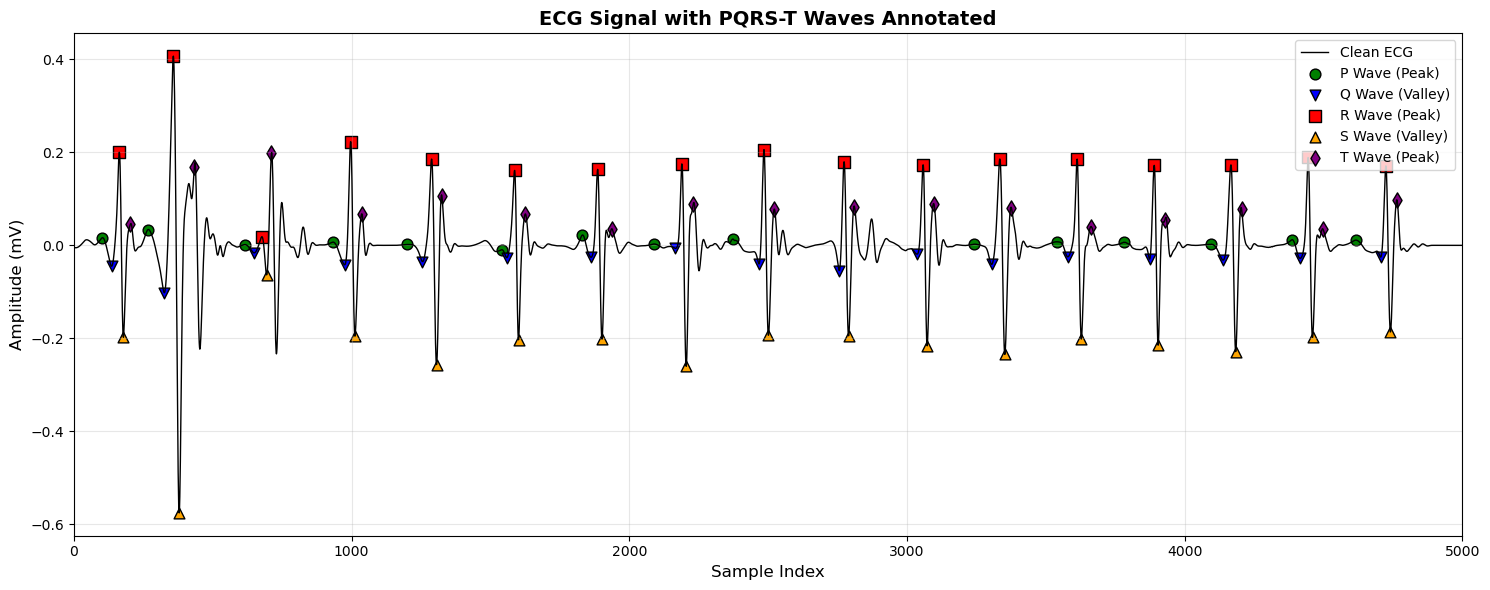

In [11]:
ecg = ECG(df['denoised_ecg'][0])
ecg.plot(xlim=(0, 5000))

In [12]:
rr_intervals = ecg.rri()
print(rr_intervals)

[0.39  0.638 0.638 0.584 0.598 0.598 0.606 0.592 0.578 0.568 0.552 0.558
 0.556 0.552 0.556 0.56 ]
